In [4]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [11]:
# Define state
class BMIState(TypedDict):
    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [3]:
def calculate_BMI(state:BMIState) -> BMIState:

    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight/(height**2)

    state['bmi'] = round(bmi, 2)

    return state

In [12]:
def label_bmi(state: BMIState) -> BMIState:

    bmi = state['bmi']

    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"

    return state

### Graph

START -->  calculate_BMI -->  END

In [21]:
# Define your Graph

graph = StateGraph(BMIState)

# add nodes to ypur graph
graph.add_node('calculate_BMI', calculate_BMI)
graph.add_node('label_bmi', label_bmi)

# add edges to your graph
graph.add_edge(START, 'calculate_BMI')
graph.add_edge('calculate_BMI', 'label_bmi')
graph.add_edge('label_bmi', END)

# compile the graph
workflow = graph.compile()


In [19]:
# execute the graph
final_state = workflow.invoke({'weight_kg':60, 'height_m':1.70})

print(final_state)

{'weight_kg': 60, 'height_m': 1.7, 'bmi': 20.76, 'category': 'Normal'}


## Visualize the graph

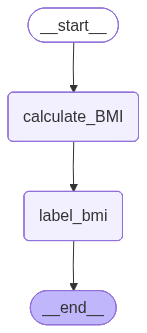

In [20]:
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))